<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week10(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Guided Backpropagation
When I execute this code and study the resulting Guided Backpropagation map alongside the original image, here is what I observe:

I observe hyper-specific edge detection, not just general outlines.
Unlike the intermediate feature maps from our earlier experiments (which highlighted the entire silhouette of the clothing), the Guided Backprop image looks almost like a glowing neon sketch. I see that the network is completely ignoring the smooth, flat fabric in the middle of the clothing item. It is placing all of its focus strictly on the sharpest contours, straps, heels, or collars.

I observe the "Why" behind the prediction.
When I run this on the Ankle Boot image, I notice that the brightest glowing pixels on the GBP map are located exactly at the pointed toe and the blocky heel of the boot. This tells me that the network isn't guessing "Boot" because of the overall blob shape; it is actively using the presence of a heel and a pointed toe to make its final decision.

I observe the power of blocking negative gradients.
In a standard gradient map (a basic Saliency Map), the image is incredibly noisy and filled with gray static. Because I mathematically forced the network to drop all negative gradients (using the @tf.custom_gradient), I observe a beautifully clean, black background. By only allowing the positive voting signals to travel backward to the pixels, the resulting image isolates exactly what the network "liked" about the image, completely removing what it "disliked."

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training standard model to learn features...


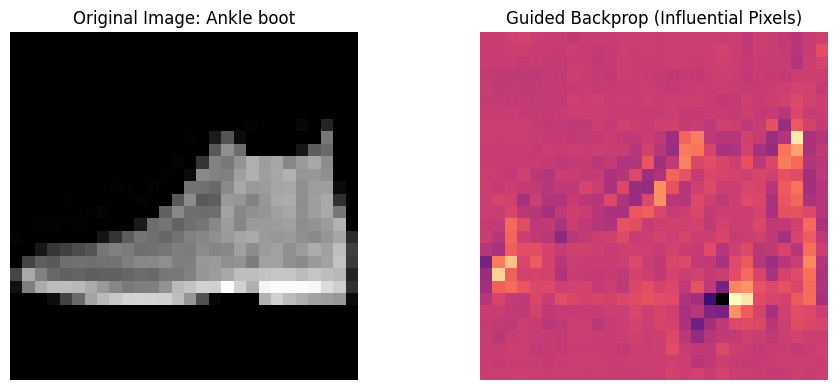

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load Data and Find a Target Image
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Let's pick a specific Ankle Boot from the test set
image_idx = 0
target_image = tf.convert_to_tensor(x_test[image_idx:image_idx+1], dtype=tf.float32)
target_class = y_test[image_idx]

# Step 2: Build and Train a Standard CNN
def build_cnn(activation_fn='relu'):
    """We wrap the model builder in a function so we can easily swap the activation function later."""
    inputs = tf.keras.Input(shape=(28, 28, 1))
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation=activation_fn)(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation=activation_fn)(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    # Notice: No softmax here! We want the raw, unbounded score for accurate gradients.
    outputs = tf.keras.layers.Dense(10, activation='linear')(x)
    return tf.keras.Model(inputs, outputs)

standard_model = build_cnn(activation_fn='relu')
standard_model.compile(optimizer='adam',
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])

print("Training standard model to learn features...")
standard_model.fit(x_train, y_train, epochs=3, batch_size=256, verbose=0)

# Step 3: Define the Guided Backpropagation Math
@tf.custom_gradient
def guided_relu(x):
    """
    Custom ReLU function. During forward pass, it acts like normal ReLU.
    During backward pass (gradients), it zeros out any negative gradients.
    """
    def grad(dy):
        # 1. Cast positive gradients (dy > 0) to 1.0, else 0.0
        # 2. Cast positive inputs (x > 0) to 1.0, else 0.0
        # Multiply them to only allow positive signals to pass through positive activations
        return tf.cast(dy > 0, dtype=tf.float32) * tf.cast(x > 0, dtype=tf.float32) * dy
    return tf.nn.relu(x), grad

# Step 4: Clone the Model and Inject Guided ReLU
# Build a twin model that uses our custom mathematical rules
guided_model = build_cnn(activation_fn=guided_relu)

# Copy the "brain" (weights) from the trained model into the guided model
guided_model.set_weights(standard_model.get_weights())

# Step 5: Execute Guided Backpropagation
# We use a GradientTape to record the math operations so we can run them in reverse
with tf.GradientTape() as tape:
    tape.watch(target_image)                 # Keep an eye on the input pixels
    predictions = guided_model(target_image) # Forward pass

    # Isolate the score of the correct class (e.g., the "Ankle Boot" score)
    loss = predictions[0, target_class]

# Calculate the gradient of the class score with respect to the input image pixels
gbp_gradients = tape.gradient(loss, target_image)

# Step 6: Process and Visualize the Results
# Convert the tensor to a numpy array and remove batch/channel dimensions
gbp_image = gbp_gradients[0].numpy()

# Normalize the image to [0, 1] so Matplotlib can display it nicely
gbp_image -= gbp_image.min()
gbp_image /= (gbp_image.max() + tf.keras.backend.epsilon())

# Plotting
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(target_image[0, :, :, 0], cmap='gray')
plt.title(f"Original Image: {class_names[target_class]}")
plt.axis('off')

plt.subplot(1, 2, 2)
# We use the 'magma' colormap to make the activated pixels glow fiercely
plt.imshow(gbp_image[:, :, 0], cmap='magma')
plt.title("Guided Backprop (Influential Pixels)")
plt.axis('off')

plt.tight_layout()
plt.show()